# Linear Regression

### Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model, metrics


In [3]:
# load the dataset
df=pd.read_csv("C:\\MCA\\DataScience\\DataSets\\house_prices_inr.csv")
df.head()

,Area,Price_INR
0,750,3194193
1,800,2502586
2,850,3969622
3,900,3588555
4,950,4021949


In [ ]:
# display basic statistics of the dataset
df.describe()

,Area,Price_INR
count,60.00000,6.000000e+01
mean,2225.00000,1.071367e+07
std,873.21246,6.872745e+06
min,750.00000,2.502586e+06
25%,1487.50000,5.778317e+06
50%,2225.00000,9.109538e+06
75%,2962.50000,1.409777e+07
max,3700.00000,3.938714e+07


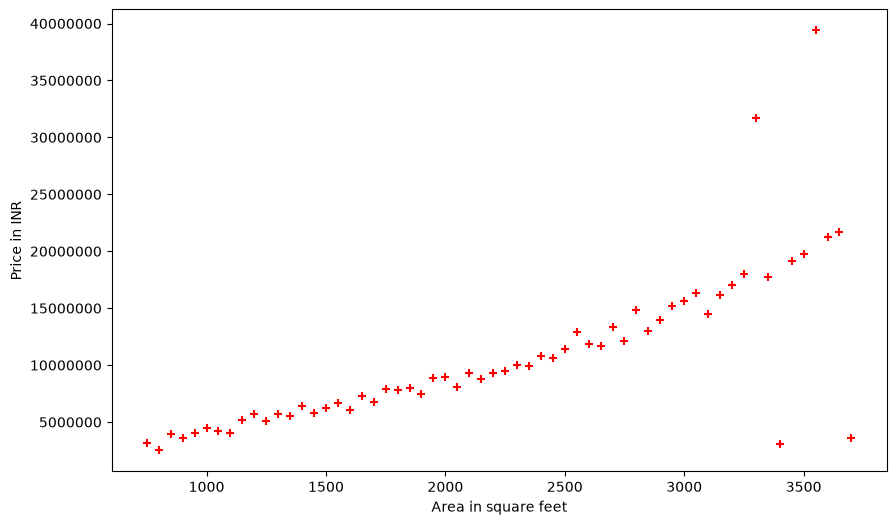

In [7]:
#visualize
plt.figure(figsize=(10,6))
plt.xlabel("Area in square feet")
plt.ylabel("Price in INR")

#Disable scientific notation
plt.ticklabel_format(style='plain', axis='y')

plt.scatter(df.Area, df.Price_INR, color='red', marker='+')

In [8]:
# Define features and target variable
X=df[['Area']]
y=df['Price_INR']

#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape[0])
print("Testing data size:", X_test.shape[0])

Training data size: 48
Testing data size: 12


In [9]:
#Initialize the model
model=linear_model.LinearRegression()

#fit the model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5910.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.6e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
#predict the values
y_pred=model.predict(X_test)
y_pred

array([ 1832400.74174528,  3309912.33691751, 12470484.22698537,
       15130005.09829539,  5673930.88919309, 17789525.96960541,
       11583977.26988203, 16016512.05539872,  5378428.57015864,
       18676032.92670875, 15425507.41732983, 16607516.69346762])

In [11]:
#r2 score
r2=model.score(X_test, y_test)
print("R2 score:", r2)

R2 score: 0.962426854646343


In [12]:
# calculate the key statical metrics
mae=metrics.mean_absolute_error(y_test, y_pred)
mse=metrics.mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 952250.8620063681
Mean Squared Error: 1343124400840.1843
Root Mean Squared Error: 1158932.4401535166


In [ ]:
#manual calculation (y=mx+c)
area=2500
m=model.coef_[0]
b=model.intercept_
y_manual=m*area+b
print(y_manual)

12174981.907950917


In [18]:
new_area=pd.read_csv("C:\\MCA\\DataScience\\DataSets\\new_areas.csv")
new_area.head()

,Area
0,750
1,1543
2,645
3,1434
4,1534


In [19]:
new_area.shape

(14, 1)

In [20]:
predicted_prices=model.predict(new_area)
predicted_prices

array([ 1832400.74174528,  6519067.52163161,  1211845.87177294,
        5874872.46613651,  6465877.10420541,  1749660.09241563,
        3002589.92512169,   278058.54362409, -1169902.8196447 ,
        6406776.64039852,  5272047.73530624,  5331148.19911313,
       -2286901.58559491, 12429113.90232054])

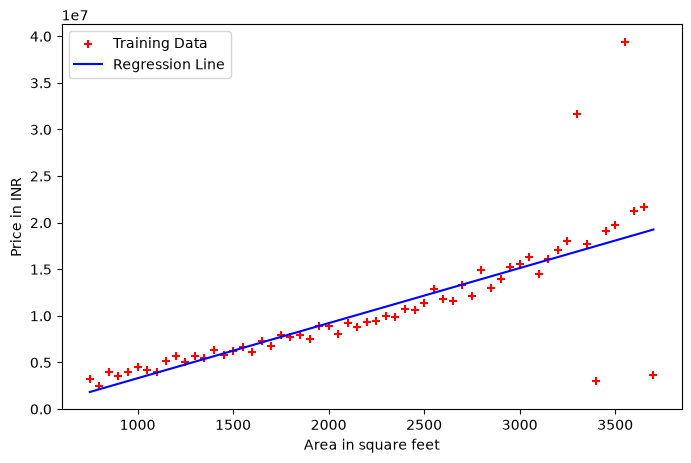

In [21]:
plt.figure(figsize=(8,5))
plt.xlabel("Area in square feet")
plt.ylabel("Price in INR")
plt.scatter(df['Area'],df['Price_INR'],color='red',marker='+',label='Training Data')
plt.plot(df.Area,model.predict(df[['Area']]),color='blue',label='Regression Line')
plt.legend()
plt.show()